# SMS Spam Detection Using Machine Learning

## Project Overview

This project develops a machine learning classification system to identify whether an SMS message is spam or legitimate.

Two machine learning algorithms, Logistic Regression and Random Forest, are trained and evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. Five-fold cross-validation is also used to evaluate model performance.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset

In [2]:
import urllib.request
import zipfile
import os

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

urllib.request.urlretrieve(url, "sms_spam.zip")

with zipfile.ZipFile("sms_spam.zip", "r") as zip_ref:
    zip_ref.extractall("sms_data")

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [3]:
file_path = "sms_data/SMSSpamCollection"

df = pd.read_csv(
    file_path,
    sep="\t",
    header=None,
    names=["label", "message"]
)

print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


## 3. Data Exploration and Preprocessing

In [4]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nClass distribution:")
print(df["label"].value_counts())


Dataset shape: (5572, 2)

Missing values:
label      0
message    0
dtype: int64

Duplicate rows: 403

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [5]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)


Dataset shape after removing duplicates: (5169, 2)


In [6]:
df["label"] = df["label"].map({"ham": 0, "spam": 1})

print(df.head())

   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


## 4. Train/Test Split

In [7]:
from sklearn.model_selection import train_test_split

X = df["message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 4135
Testing data: 1034


## 5. TF-IDF Feature Extraction

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

Training data shape: (4135, 7680)
Testing data shape: (1034, 7680)


## 6. Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## 7. Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_tfidf, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


## 8. Model Predictions

In [11]:
# Predictions from both models

lr_pred = lr_model.predict(X_test_tfidf)
rf_pred = rf_model.predict(X_test_tfidf)

# Probability of spam
lr_prob = lr_model.predict_proba(X_test_tfidf)[:, 1]
rf_prob = rf_model.predict_proba(X_test_tfidf)[:, 1]

print("Predictions completed successfully!")

Predictions completed successfully!


## 9. Model Evaluation

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Logistic Regression metrics
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_roc_auc = roc_auc_score(y_test, lr_prob)

# Random Forest metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("LOGISTIC REGRESSION")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))
print("ROC-AUC  :", round(lr_roc_auc, 4))

print("\nRANDOM FOREST")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

LOGISTIC REGRESSION
Accuracy : 0.9642
Precision: 0.9608
Recall   : 0.7481
F1 Score : 0.8412
ROC-AUC  : 0.9874

RANDOM FOREST
Accuracy : 0.971
Precision: 0.9903
Recall   : 0.7786
F1 Score : 0.8718
ROC-AUC  : 0.9902


## 10. Cross-Validation

In [13]:
from sklearn.model_selection import cross_val_score

lr_cv = cross_val_score(
    lr_model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="accuracy"
)

rf_cv = cross_val_score(
    rf_model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression CV Accuracy:", round(lr_cv.mean(), 4))
print("Random Forest CV Accuracy:", round(rf_cv.mean(), 4))

Logistic Regression CV Accuracy: 0.9516
Random Forest CV Accuracy: 0.9703


## 11. Confusion Matrix

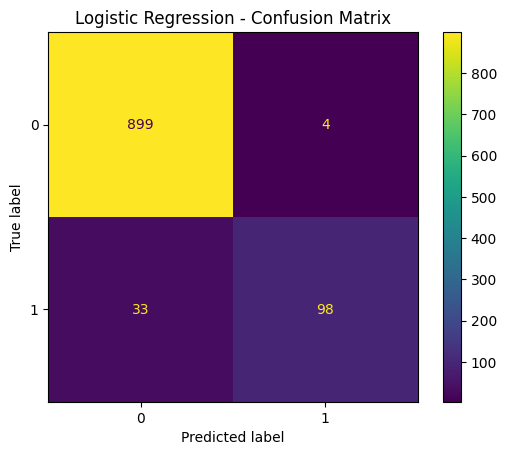

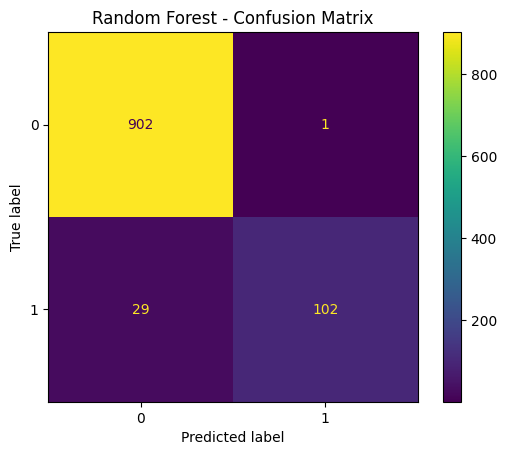

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title("Random Forest - Confusion Matrix")
plt.show()

## 12. ROC Curve

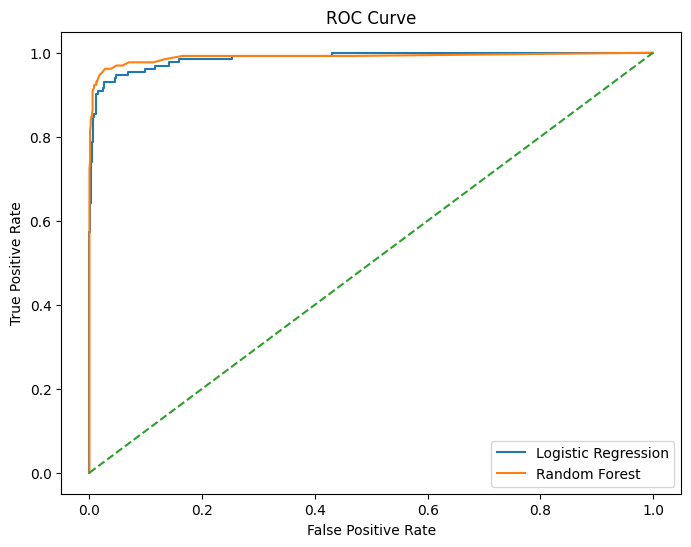

In [15]:
from sklearn.metrics import roc_curve

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))

plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 13. Model Comparison

In [16]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy],
    "Precision": [lr_precision, rf_precision],
    "Recall": [lr_recall, rf_recall],
    "F1 Score": [lr_f1, rf_f1],
    "ROC-AUC": [lr_roc_auc, rf_roc_auc]
})

print(results.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.9642     0.9608  0.7481    0.8412   0.9874
1        Random Forest    0.9710     0.9903  0.7786    0.8718   0.9902


### Model Performance Comparison Graph

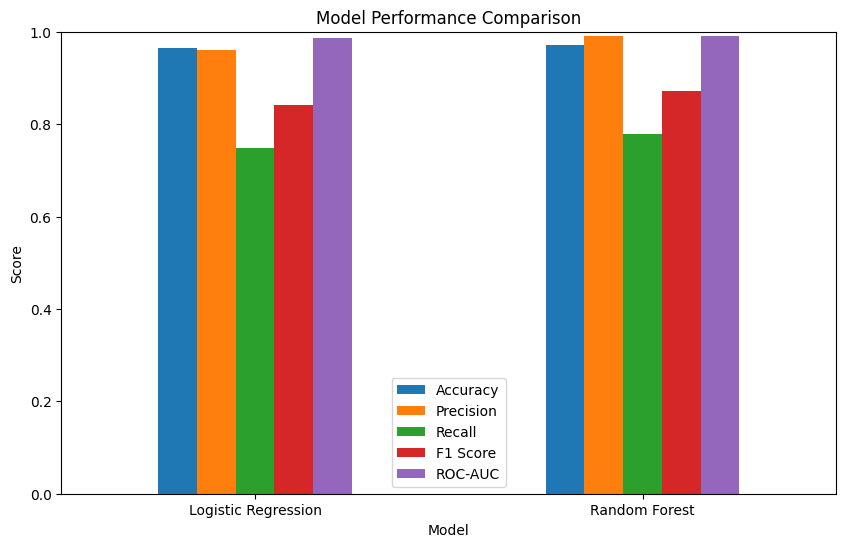

In [18]:
results_plot = results.set_index("Model")

results_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

# SMS Spam Detection Using Machine Learning

## Project Overview

This project develops a machine learning classification system to identify whether an SMS message is spam or legitimate.

Two machine learning algorithms, Logistic Regression and Random Forest, are trained and evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. Five-fold cross-validation is also used to evaluate model performance.

## Algorithms Used

* Logistic Regression
* Random Forest

## Technologies Used

* Python
* Google Colab
* Pandas
* NumPy
* Scikit-learn
* Matplotlib
* Seaborn

## Dataset

SMS Spam Collection Dataset


## 14. Conclusion

This project developed a machine learning system for detecting spam SMS messages. The dataset was preprocessed and converted into numerical features using TF-IDF. Two classification algorithms, Logistic Regression and Random Forest, were trained and evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. Five-fold cross-validation was also performed to check the consistency of the models. The results show that machine learning can be effectively used for automated spam message detection.

## 15. Future Scope

The system can be improved by using a larger and more diverse SMS dataset, testing additional machine learning algorithms, and deploying the trained model as a web or mobile application for real-time spam detection.